# Exploratory Data Analysis

Feature set: 'data/processed/features.csv'. One row per song: 39 handcrafted features
+ filename (id) + composer (label). This vector is the handcrafted half of the hybrid
model; the piano rolls under 'data/processed/rolls/' are the other half. Feature
definitions live in docs/input-pipeline-design.md.

Goal of this notebook is to decide what is actually ready for modeling:
class balance, missing/degenerate columns, feature distributions & scale, and
collinearity (the histogram families have known exact dependencies) so we can settle
the drop list and scaling before training. Ends with a visual sanity check of the rolls.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("../data/processed/features.csv")
print(df.shape)
df.head()

(1628, 41)


,filename,mi_0,mi_1,mi_2,mi_3,mi_4,mi_5,mi_6,mi_7,mi_8,...,key_fit,key_major_leaning,dur_sixteenth,dur_eighth,dur_quarter,dur_half,dur_entropy,offbeat_rate,tempo,composer
0,042100b_.mid,0.119318,0.295455,0.363636,0.028409,0.022727,0.085227,0.000000,0.068182,0.005682,...,0.896137,-0.275602,0.011111,0.305556,0.627778,0.033333,1.302049,0.005556,143.000038,bach
1,043100b_.mid,0.041916,0.281437,0.425150,0.029940,0.053892,0.059880,0.005988,0.077844,0.005988,...,0.930355,0.275881,0.058480,0.368421,0.479532,0.093567,1.598512,0.035088,189.176471,bach
2,027400b_.mid,0.141243,0.271186,0.384181,0.050847,0.050847,0.039548,0.000000,0.039548,0.000000,...,0.918987,-0.303293,0.066298,0.502762,0.392265,0.038674,1.469391,0.033149,177.509434,bach
3,Bwv0997 Partita for Lute 1mov.mid,0.023909,0.278586,0.294179,0.069647,0.058212,0.059252,0.032225,0.040541,0.022869,...,0.851272,-0.259597,0.668373,0.144319,0.187308,0.000000,1.244177,0.346981,160.264901,bach
4,Bwv1066 Orchestral Suite n1 6mov.mid,0.073171,0.242707,0.412721,0.044237,0.021760,0.071019,0.020086,0.043998,0.011478,...,0.865730,0.237688,0.002936,0.486239,0.468624,0.040183,1.247362,0.001468,168.042055,bach


## 1. Columns, dtypes, missing values

NaN is expected by design in the features that can fail on edge cases (tempo, key fit,
beat grid); imputation belongs to the modeling pipeline, fit on train only. Anything
else with NaN is a bug.

In [4]:
ID_COL, LABEL_COL = "filename", "composer"
feature_cols = [c for c in df.columns if c not in (ID_COL, LABEL_COL)]

print(f"{len(feature_cols)} feature columns")

print("\nmissing values per column:")
missing = df[feature_cols].isna().sum()
print(missing[missing > 0].to_string() if missing.any() else "none")

39 feature columns

missing values per column:
vi_dissonance    2


Our data has 1,628 songs and 39 feature columns. The only NaNs are 'vi_dissonance' on 2 fully monophonic songs (no simultaneous notes, so no vertical intervals), which is the NaN policy working as intended. Tempo, key fit, and the beat grid never failed on this corpus.

## 2. Class balance

How many songs per composer? Imbalance drives metric choice and whether we stratify the split.

composer
bach         1024
mozart        256
beethoven     212
chopin        136
Name: count, dtype: int64

proportion:
composer
bach         0.629
mozart       0.157
beethoven    0.130
chopin       0.084
Name: count, dtype: float64


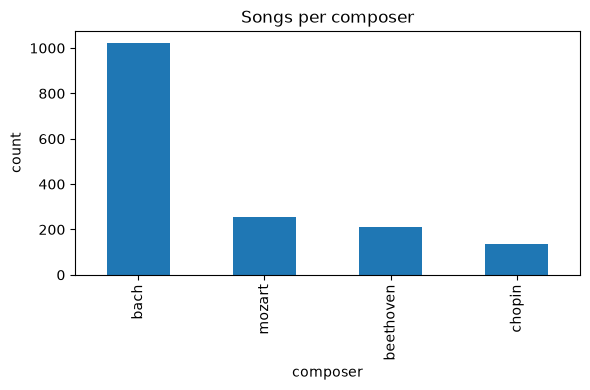

In [5]:
counts = df[LABEL_COL].value_counts()
print(counts)
print("\nproportion:")
print((counts / len(df)).round(3))

ax = counts.plot(kind="bar", figsize=(6, 4))
ax.set_title("Songs per composer")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

**There is an imbalace.** Bach is 63% of songs. We stratify the split by composer, use class weights, and judge by macro-F1 / balanced accuracy rather than accuracy.

## 3. Degenerate columns (constant / near constant)

A feature with one value (or almost one) carries no signal and should be dropped.

In [6]:
nun = df[feature_cols].nunique().sort_values()
constant = nun[nun <= 1].index.tolist()
print("constant columns:", constant or "none")

# near constant: one value covers >99% of rows
near_const = []
for c in feature_cols:
    top_frac = df[c].value_counts(normalize=True).iloc[0]
    if top_frac > 0.99:
        near_const.append((c, round(top_frac, 4)))
print("near constant (>99% one value):", near_const or "none")

nun.head(10)

constant columns: none
near constant (>99% one value): none


mi_11             923
mi_13plus        1110
mi_10            1113
mi_6             1225
mi_9             1267
mi_8             1270
offbeat_rate     1389
dur_sixteenth    1402
tempo            1416
mi_12            1421
dtype: int64

No constant or near constant columns. The fewest distinct values is 'mi_11' at 923 of 1,628 songs, a rare interval share that is zero for many pieces. Every feature varies, so nothing gets dropped on degeneracy grounds.

## 4. Summary statistics & feature scale

Features live on very different scales (histogram shares in [0,1] vs 'tempo' in the
hundreds). This matters for any gradient based model.

In [7]:
desc = df[feature_cols].describe().T[["mean", "std", "min", "max"]]
desc["range"] = desc["max"] - desc["min"]
desc.sort_values("range", ascending=False).head(15)

,mean,std,min,max,range
tempo,186.038134,38.488612,52.360524,295.820789,243.460265
vi_dissonance,0.201391,0.148676,0.010870,4.000000,3.989130
mi_entropy,2.723413,0.365520,1.300699,3.629944,2.329244
dur_entropy,1.369131,0.373660,0.037856,2.274318,2.236463
pc_entropy,3.054573,0.182729,2.389994,3.581217,1.191223
dur_sixteenth,0.381281,0.319600,0.000000,0.996476,0.996476
dur_eighth,0.295333,0.168796,0.000000,0.947332,0.947332
dur_quarter,0.255547,0.212249,0.000000,0.891608,0.891608
vi_2,0.043579,0.025968,0.000000,0.800000,0.800000
offbeat_rate,0.198111,0.185243,0.000000,0.794776,0.794776


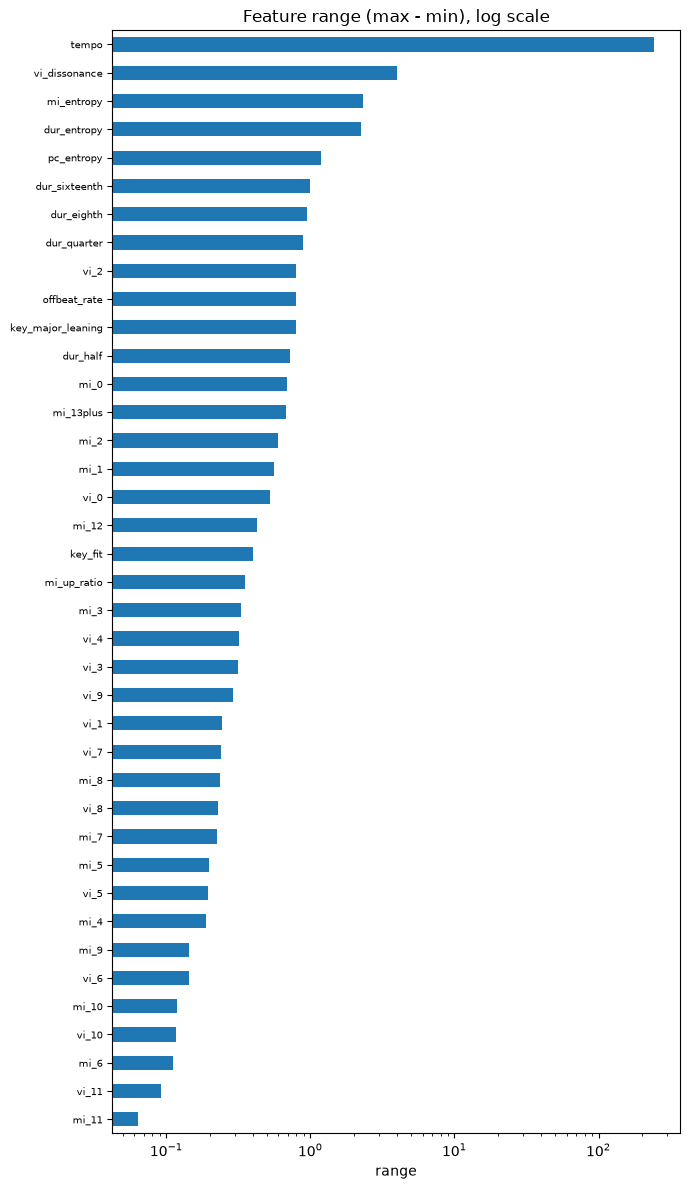

In [8]:
# Visualize scale spread across features (log axis)
ranges = (df[feature_cols].max() - df[feature_cols].min()).sort_values()
ax = ranges.plot(kind="barh", figsize=(7, 12))
ax.set_xscale("log")
ax.set_title("Feature range (max - min), log scale")
ax.set_xlabel("range")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

Wide spread confirms we need scaling: 'tempo' reaches 296 while the histogram shares live in [0,1] and the three entropies in [0, 3.6]. 'vi_dissonance' is a ratio rather than a share, so it is unbounded above and reaches 4.0. Scaling is fit on the train split only, inside the modeling pipeline.

## 5. Distributions

Histograms per feature to spot skew, multimodality, and outliers.

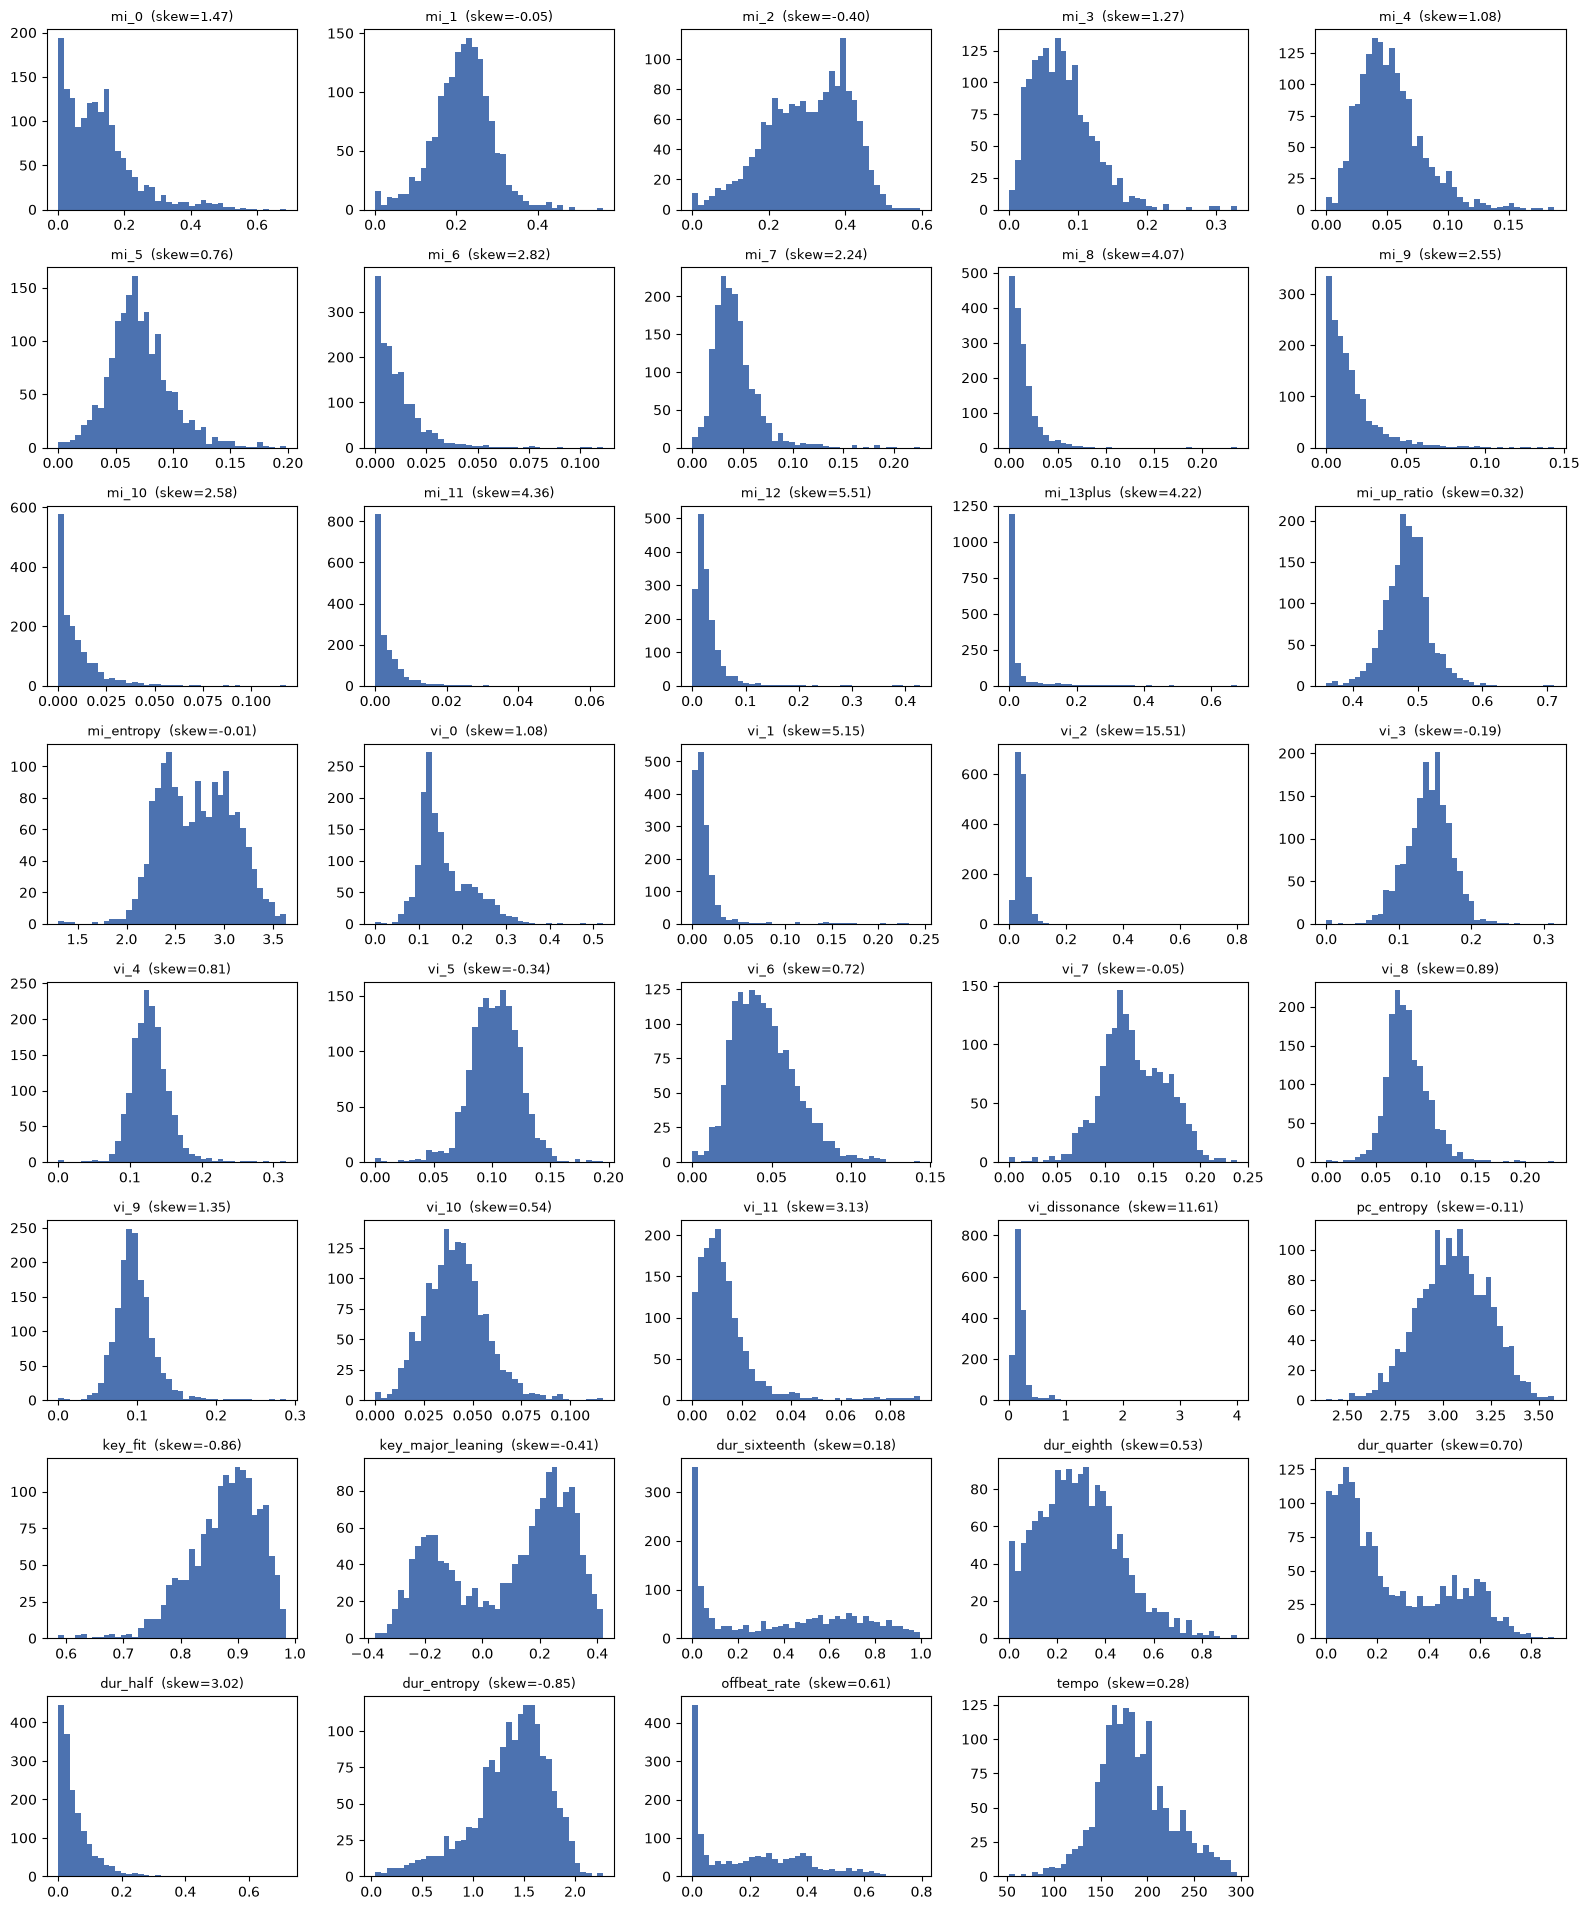

In [9]:
n = len(feature_cols)
ncol = 5
nrow = int(np.ceil(n / ncol))
skew = df[feature_cols].skew()
fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.4 * nrow))
for ax, c in zip(axes.ravel(), feature_cols):
    ax.hist(df[c].dropna(), bins=40, color="#4c72b0")
    ax.set_title(f"{c}  (skew={skew[c]:.2f})", fontsize=9)
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

Most features are well behaved. The exceptions:

- **Heavy right tails**: 'vi_2' (skew 15.5), 'vi_dissonance' (11.6), 'mi_12' (5.5), 'vi_1' (5.2), 'mi_11' (4.4), 'mi_13plus' (4.2), 'mi_8' (4.1). These are shares of rare events, so most songs sit near zero with a long tail. Candidates for PowerTransformer(yeo-johnson) in the pipeline.
- **Mild left skew**: 'key_fit' (-0.86) and 'dur_entropy' (-0.85). No transform needed.
- Bounded shares (the 'mi_*', 'vi_*', 'dur_*' bins) keep their shape; scale only.

Dropping the descriptive block removed the zero inflated velocity columns, which were the only features needing a flag to explain a spike at zero.

## 6. Correlation & collinearity

The two interval histogram families carry exact dependencies by construction: each sums
to 1, so one bin is determined by the rest. A dense head consumes this vector, so we
settle the drop list here with correlation pairs and VIF.

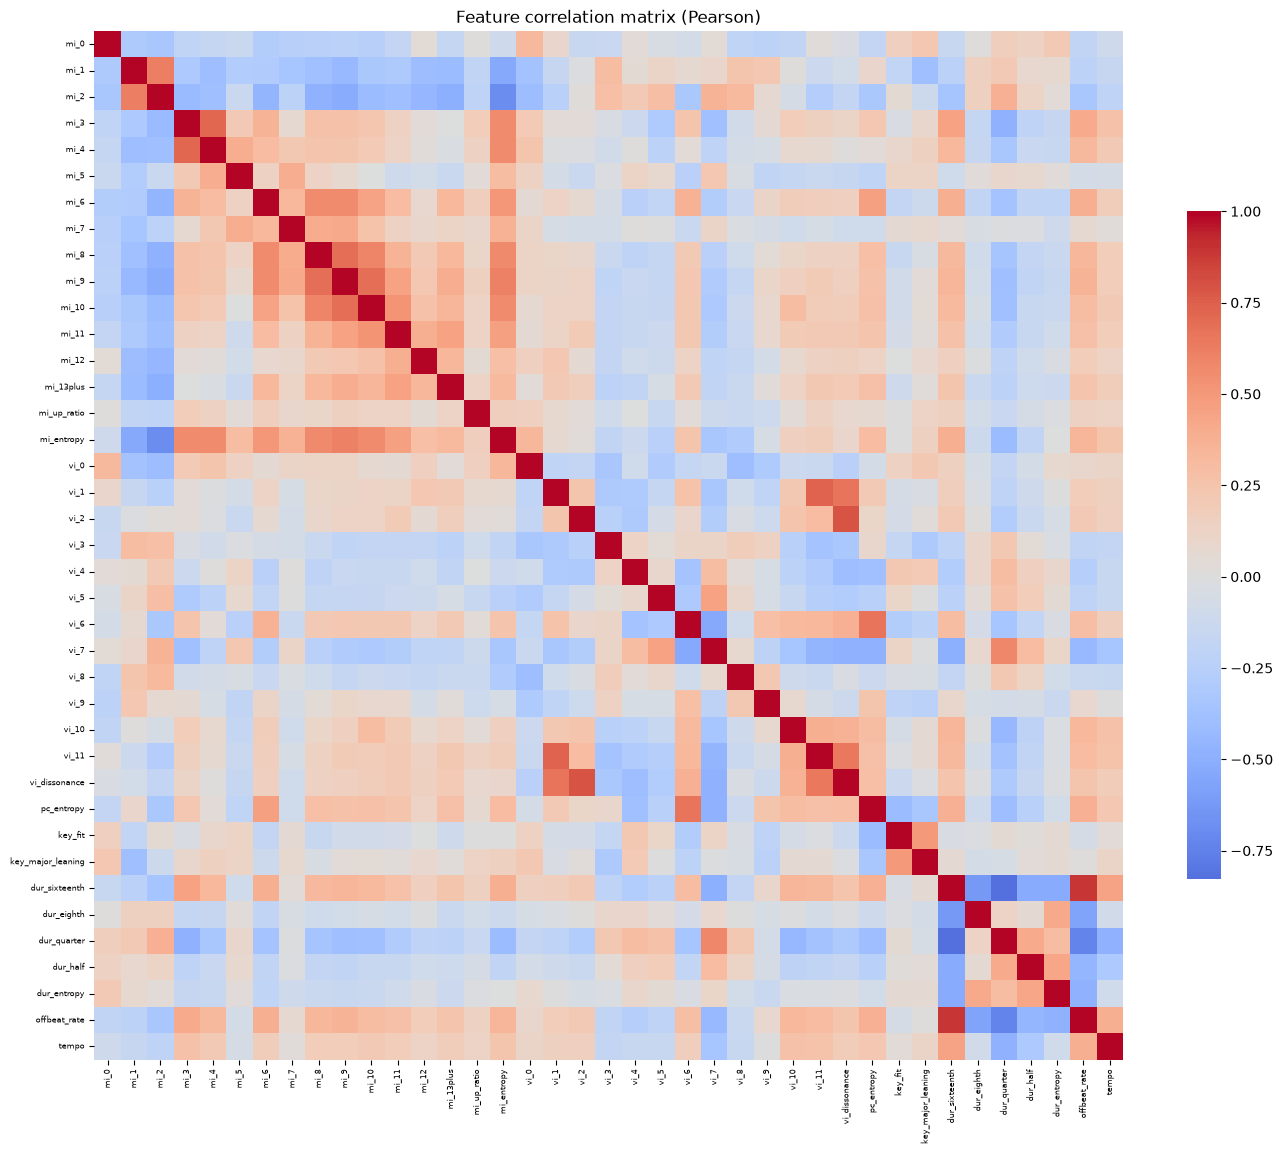

In [10]:
corr = df[feature_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
plt.tick_params(labelsize=6)
plt.title("Feature correlation matrix (Pearson)")
plt.tight_layout()
plt.show()

In [11]:
# Flag highly correlated pairs
THRESH = 0.85
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "corr"})
)
high = pairs[pairs["corr"].abs() >= THRESH].sort_values("corr", key=abs, ascending=False)
print(f"pairs with |corr| >= {THRESH}:")
high

pairs with |corr| >= 0.85:


,feat_a,feat_b,corr
1285,dur_sixteenth,offbeat_rate,0.890674


In [17]:
# Variance Inflation Factor (VIF): multicollinearity, not just pairwise

def vif_table(X):
    X = X.dropna().copy()
    X = (X - X.mean()) / X.std(ddof=0)  # standardize for comparability
    vifs = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        vifs[c] = np.inf if r2 >= 1 else 1.0 / (1.0 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

vif = vif_table(df[feature_cols])
print("VIF > 10 indicates problematic multicollinearity:")
vif.head(30)

VIF > 10 indicates problematic multicollinearity:


mi_0                    inf
vi_0                    inf
vi_11                   inf
vi_10                   inf
vi_9                    inf
vi_8                    inf
vi_7                    inf
vi_6                    inf
vi_5                    inf
vi_4                    inf
mi_1                    inf
vi_2                    inf
vi_1                    inf
vi_3                    inf
mi_3                    inf
mi_8                    inf
mi_2                    inf
mi_5                    inf
mi_6                    inf
mi_7                    inf
mi_4                    inf
mi_9                    inf
mi_10                   inf
mi_11                   inf
mi_12                   inf
mi_13plus               inf
dur_sixteenth    335.510031
dur_quarter      152.541842
dur_eighth        90.632010
dur_half          16.858198
dtype: float64

Two exact dependencies remain, both compositional: the 'mi_*' family (14 bins) and the 'vi_*' family (12 bins) each sum to 1, so one bin of each is fixed by the others. 26 of the 39 features report infinite VIF as a result. The 'dur_*' bins no longer close, because the whole note bin is computed for the entropy but not emitted.

**Drop list for the modeling pipeline (2): 'mi_11', 'vi_11'.** That leaves 37 features with no exact dependency, and max VIF falls from infinite to 784.

**Correction to the earlier 66 feature run.** That analysis attributed the residual inflation to the histogram summary statistics ('mi_mean', 'mi_std', 'mi_entropy') overlapping their own bins. Removing 'mi_mean' and 'mi_std' from extraction entirely moved max VIF only from 864 to 784, and the top offenders are unchanged: 'mi_2', 'mi_0', 'mi_1', 'mi_13plus', 'dur_sixteenth'. The inflation is **compositional closure**, not the summary stats: bins are shares of a fixed total, so they near determine one another even once the exact dependency is gone. This is tolerable for a dense head and would not be for a linear model or for reading coefficients as importances.

One pair exceeds |corr| 0.85: 'dur_sixteenth' with 'offbeat_rate' (0.89). That is musical rather than structural, since fast notes are the ones that land off the beat grid. Both are kept.

## 7. Do features separate the composers?

Standardized per class means: which features actually differ across composers
(i.e. carry signal for classification)?

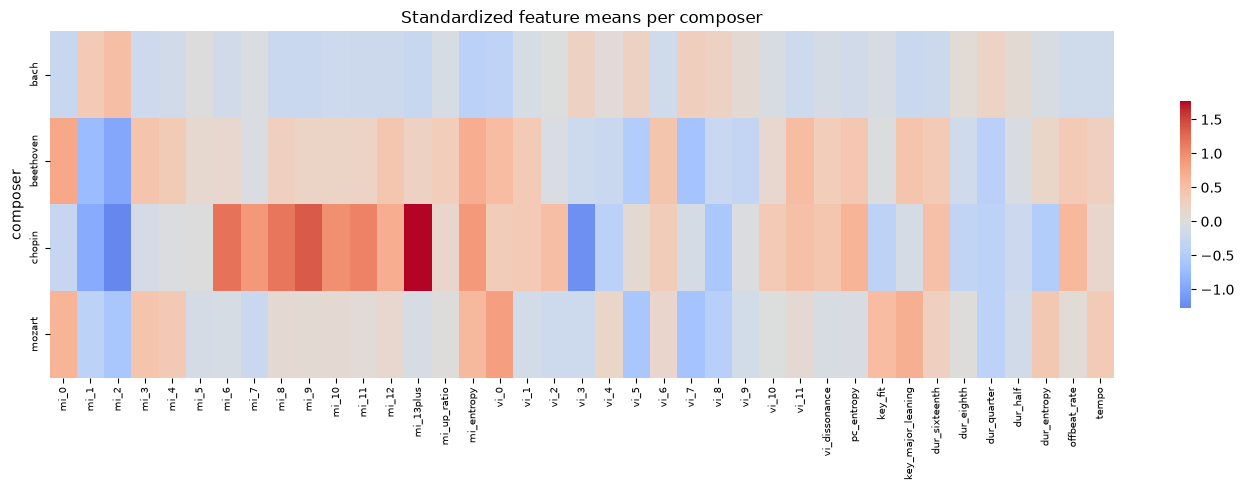

mi_13plus            0.930383
mi_2                 0.783914
mi_9                 0.701764
mi_6                 0.632918
vi_3                 0.608804
mi_8                 0.604888
mi_1                 0.574491
mi_entropy           0.572849
mi_0                 0.560702
mi_11                0.546263
vi_0                 0.518196
mi_7                 0.514612
mi_10                0.495487
vi_7                 0.459997
key_major_leaning    0.440565
dtype: float64

In [13]:
z = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std(ddof=0)
z[LABEL_COL] = df[LABEL_COL]
class_means = z.groupby(LABEL_COL)[feature_cols].mean()

plt.figure(figsize=(14, 5))
sns.heatmap(class_means, cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.6})
plt.tick_params(labelsize=7)
plt.title("Standardized feature means per composer")
plt.tight_layout()
plt.show()

# Rank features by how much their class means spread (proxy for discriminative power)
class_means.std().sort_values(ascending=False).head(15)

The strongest separators are the melodic interval features, exactly what the research promised. 'mi_13plus' (0.93), 'mi_2' (0.78), and 'mi_9' (0.70) top the ranking, all driven by **Chopin**, who sits +1.78 std on 'mi_13plus' (very large leaps), +1.37 on 'mi_9', and -1.28 on 'mi_2' (almost no stepwise motion). **Bach is the mirror image**: 'mi_2' +0.52, the most stepwise composer in the set.

The theory features carve up the middle of the field, which is where the old descriptive stats were weakest:

- **Mozart owns tonality**: 'key_fit' +0.54 and 'key_major_leaning' +0.68, the clearest major key commitment of the four.
- **Beethoven owns chromaticism**: 'pc_entropy' +0.40 with 'key_major_leaning' +0.44, spreading across pitch classes while staying major leaning.
- **'vi_dissonance' orders the composers by era** (bach -0.11, mozart -0.06, beethoven +0.32, chopin +0.43), a sanity check against music history.


## 8. Roll sanity check

Load a few rolls from the manifest and render the frame channel: pitch on the vertical,
time on the horizontal. If these don't look like music, the CNN input is broken.

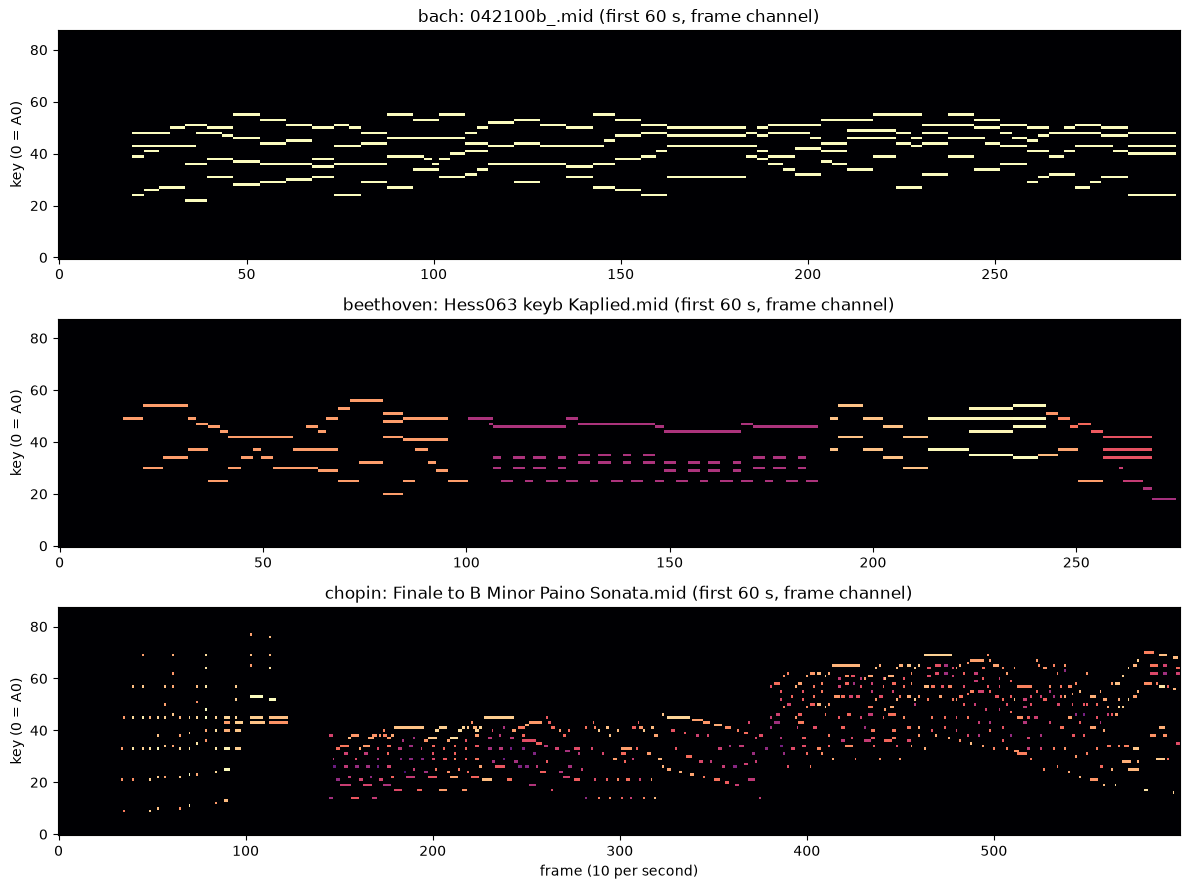

            count    mean     std    min     25%     50%     75%      max
composer                                                                 
bach       1024.0  1562.0  2450.0  175.0   425.0   768.0  1895.0  52094.0
beethoven   212.0  5085.0  4925.0  219.0  2106.0  3974.0  6714.0  50324.0
chopin      136.0  2209.0  1845.0  234.0   927.0  1576.0  3122.0  13528.0
mozart      256.0  4009.0  2731.0  261.0  2070.0  3478.0  5296.0  14782.0


In [14]:
manifest = pd.read_csv("../data/processed/rolls_manifest.csv")
picks = manifest.groupby("composer").first().reset_index().iloc[:3]

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for ax, (_, row) in zip(axes, picks.iterrows()):
    arr = np.load("../" + row["path"])["roll"]
    ax.imshow(arr[1, :, :600], aspect="auto", origin="lower", cmap="magma",
              interpolation="nearest")
    ax.set_title(f"{row['composer']}: {row['filename']} (first 60 s, frame channel)")
    ax.set_ylabel("key (0 = A0)")
axes[-1].set_xlabel("frame (10 per second)")
plt.tight_layout()
plt.show()

print(manifest.groupby("composer")["n_frames"].describe().round(0))

In [ ]:
# Crop coverage: we want the training loader takes random 30 second crops (300 frames)
CROP = 300
short = manifest[manifest["n_frames"] < CROP]
print(f"songs shorter than one crop: {len(short)} of {len(manifest)}")
print(short.groupby("composer").size().to_string())
print(f"shortest song: {manifest['n_frames'].min()} frames")

total = manifest.groupby("composer")["n_frames"].sum()
print("\nshare of songs vs share of frames:")
print(pd.DataFrame({
    "songs": manifest["composer"].value_counts(normalize=True).round(3),
    "frames": (total / total.sum()).round(3),
}).to_string())


songs shorter than one crop: 70 of 1628
composer
bach         63
beethoven     4
chopin        2
mozart        1
shortest song: 175 frames

share of songs vs share of frames:
           songs  frames
composer                
bach       0.629   0.400
beethoven  0.130   0.269
chopin     0.084   0.075
mozart     0.157   0.256


Three loader constraints fall out of the crop numbers:

- **70 songs are shorter than one crop** (63 of them bach chorales, shortest 18 s). The loader pads these to 300 frames.
- **Crop sampling sets the class balance.** Bach is 63% of songs but only 40% of frames. We sample **one random crop per song per epoch**, so the batch distribution stays the song distribution and the class weights from section 2 remain valid.

## Summary

**Data:** 1,628 songs, 39 handcrafted music theory features + 1,628 piano rolls (2 x 88 x T uint8). No degenerate columns; 2 NaNs total, by policy.

**Feature scope:** the vector will carry only what the CNN cannot read off the roll: skyline melodic intervals, vertical interval classes and dissonance, Krumhansl key fit, and beat relative rhythm. Pitch statistics, texture, polyphony, note density, and velocity were removed because the roll already shows them.

**Drop list (applied in the pipeline, not the CSV):** 'mi_11', 'vi_11', the two compositional dependencies. 37 model features remain, max VIF 784.

**Modeling Choices**
- **Imbalance** (bach 63%): stratify the song split, class weights, macro-F1.
- **Scale + skew**: PowerTransformer(yeo-johnson) for the heavy right tails ('vi_2', 'vi_dissonance', rare interval bins), StandardScaler for the rest; fit on train only, with NaN imputation (train median) ahead of it.
- **Rolls**: train on random 30 second crops (300 frames), one crop per song per epoch, padding the 70 songs shorter than a crop; average crop predictions per song at eval.
- **Split by song, stratified by composer**; the feature vector and the roll of a song always stay on the same side of the split.